In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_excel("taxi fare 1data (1) (1).xlsx")

# Display first 5 rows
df.head()

,Trip_ID,Distance_km,Duration_min,Passengers,Traffic_Level,Peak_Hour,Weather,Fare
0,1,19.54,54.90,1,Medium,Yes,Clear,576.54
1,2,13.24,40.20,1,Medium,Yes,Cloudy,445.03
2,3,13.17,54.30,2,Medium,No,Clear,476.24
3,4,28.76,107.40,3,Medium,Yes,Cloudy,863.92
4,5,16.55,91.00,5,High,No,Clear,630.62


In [3]:
# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Dataset information
df.info()

Number of rows: 500
Number of columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Trip_ID        500 non-null    int64  
 1   Distance_km    500 non-null    float64
 2   Duration_min   500 non-null    float64
 3   Passengers     500 non-null    int64  
 4   Traffic_Level  500 non-null    object 
 5   Peak_Hour      500 non-null    object 
 6   Weather        500 non-null    object 
 7   Fare           500 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 31.4+ KB


In [5]:
# Display column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Trip_ID', 'Distance_km', 'Duration_min', 'Passengers', 'Traffic_Level', 'Peak_Hour', 'Weather', 'Fare']


In [6]:
# Numerical columns
numerical_columns = ['Distance_km', 'Duration_min', 'Passengers', 'Fare']

# Calculate statistics
statistics = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Variance': df[numerical_columns].var(),
    'Standard Deviation': df[numerical_columns].std(),
    'Minimum': df[numerical_columns].min(),
    'Maximum': df[numerical_columns].max()
})

statistics

,Mean,Median,Mode,Variance,Standard Deviation,Minimum,Maximum
Distance_km,14.99,14.88,7.92,72.23,8.50,1.00,29.93
Duration_min,65.14,63.35,150.00,1395.12,37.35,5.00,150.00
Passengers,2.99,3.00,1.00,2.08,1.44,1.00,5.00
Fare,502.89,499.24,525.98,53780.65,231.91,105.49,977.05


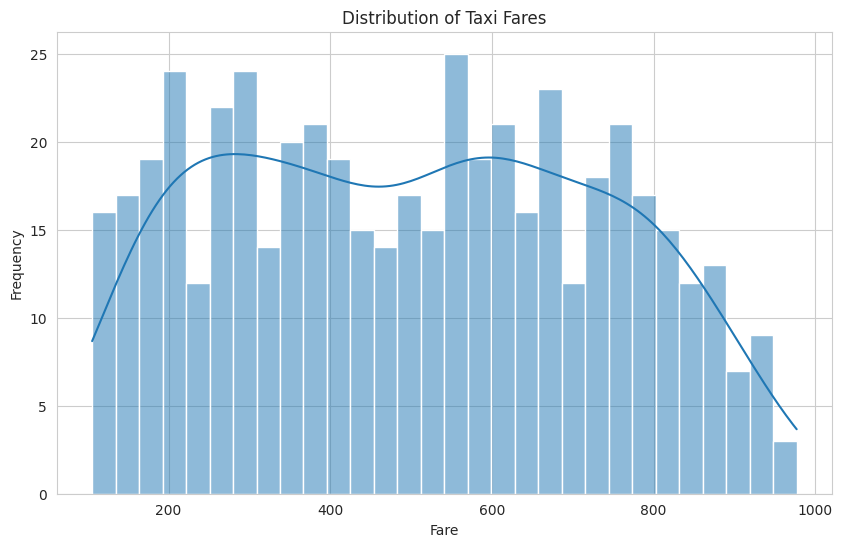

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title('Distribution of Taxi Fares')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

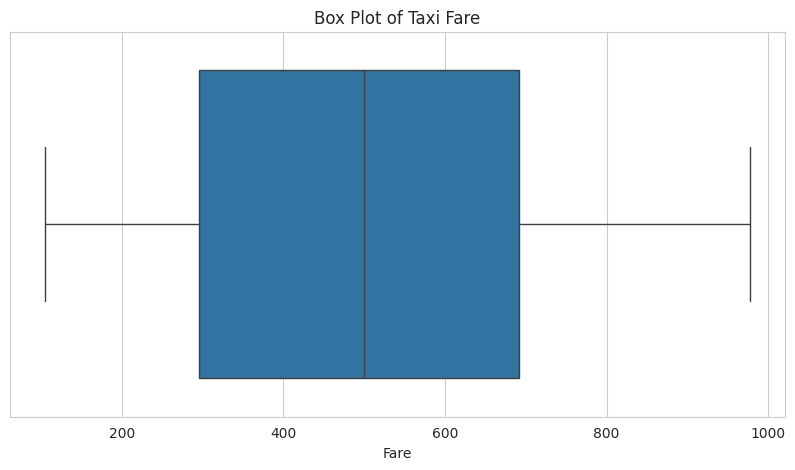

In [8]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Fare'])

plt.title('Box Plot of Taxi Fare')
plt.xlabel('Fare')

plt.show()

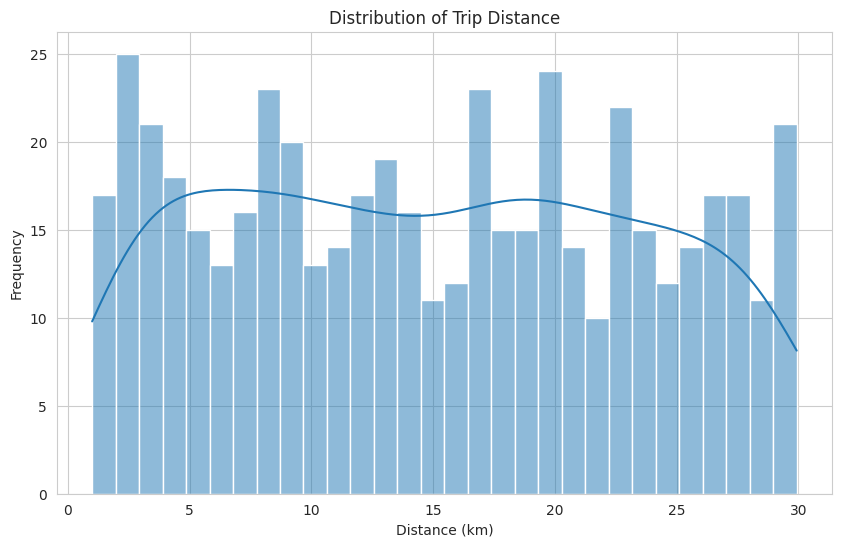

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Distance_km'], bins=30, kde=True)

plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')

plt.show()

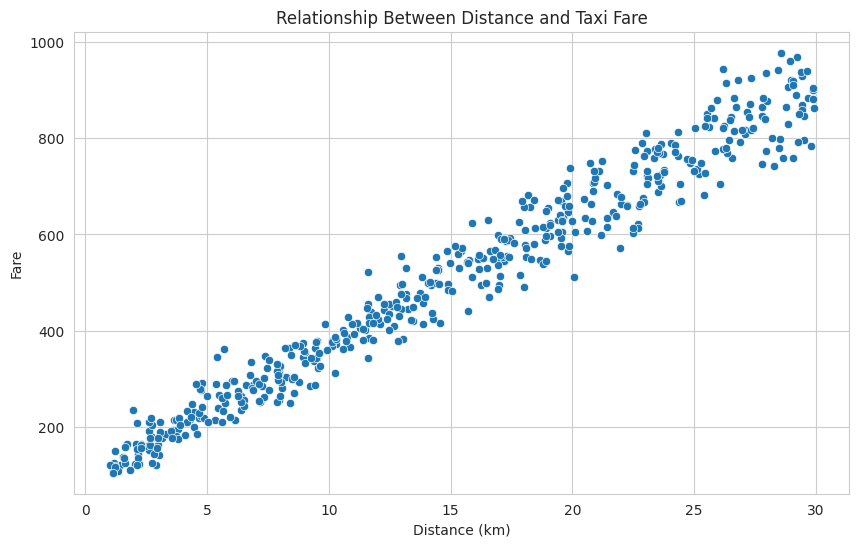

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Distance_km',
    y='Fare'
)

plt.title('Relationship Between Distance and Taxi Fare')
plt.xlabel('Distance (km)')
plt.ylabel('Fare')

plt.show()

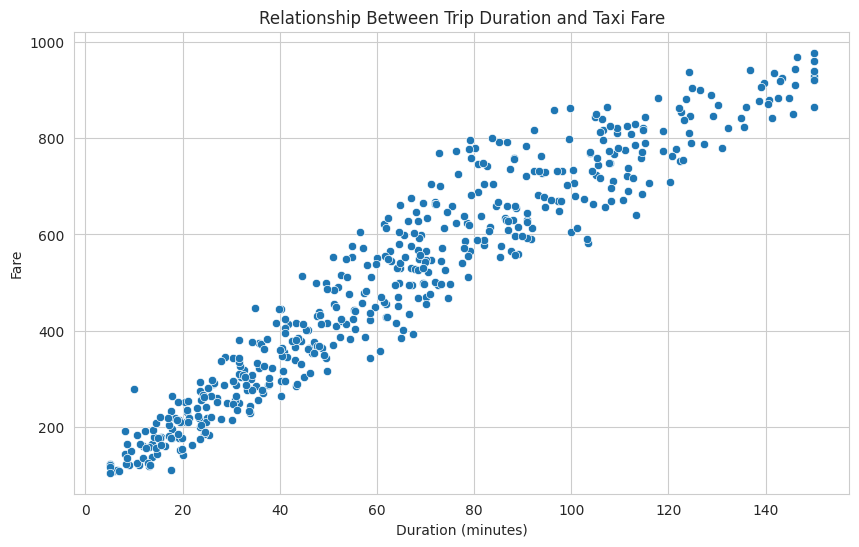

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Duration_min',
    y='Fare'
)

plt.title('Relationship Between Trip Duration and Taxi Fare')
plt.xlabel('Duration (minutes)')
plt.ylabel('Fare')

plt.show()

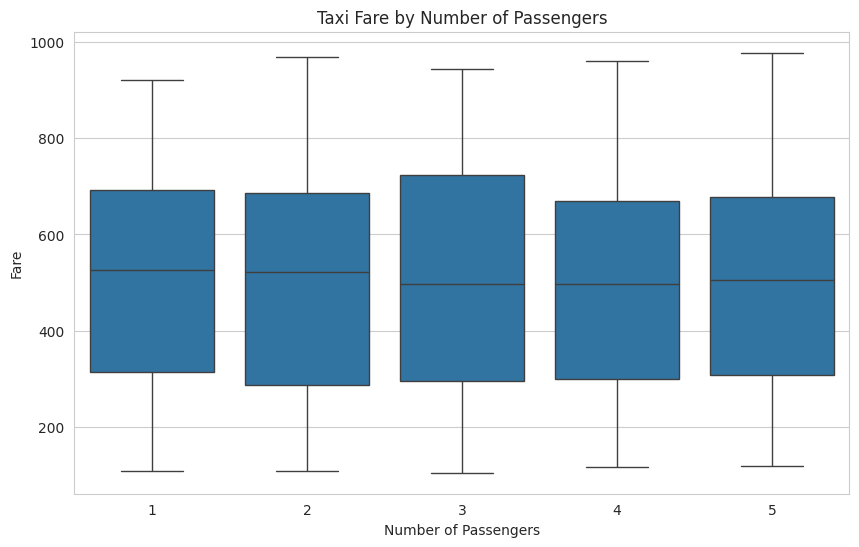

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Passengers',
    y='Fare'
)

plt.title('Taxi Fare by Number of Passengers')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare')

plt.show()

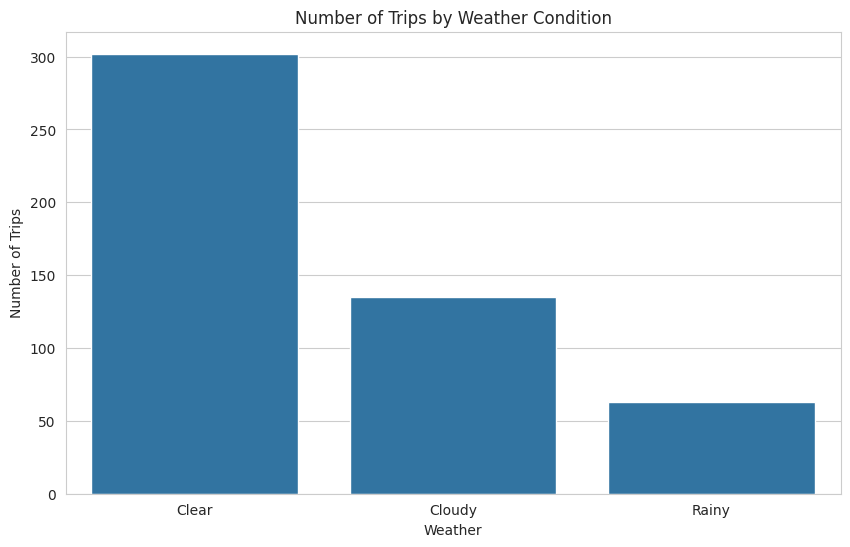

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='Weather'
)

plt.title('Number of Trips by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Number of Trips')

plt.show()

In [17]:
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
correlation_matrix = numeric_df.corr()

correlation_matrix

,Trip_ID,Distance_km,Duration_min,Passengers,Fare
Trip_ID,1.00,0.03,0.03,-0.03,0.02
Distance_km,0.03,1.00,0.91,-0.03,0.98
Duration_min,0.03,0.91,1.00,-0.02,0.96
Passengers,-0.03,-0.03,-0.02,1.00,0.01
Fare,0.02,0.98,0.96,0.01,1.00


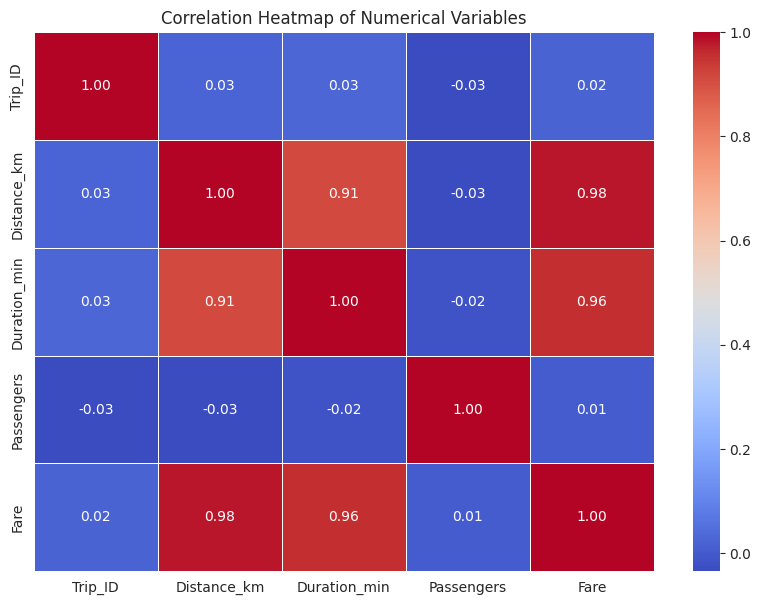

In [24]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

In [25]:
from sklearn.linear_model import LinearRegression

In [27]:
X = df[["Distance_km"]]
y = df["Fare"]

In [29]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 101.04790400426452
Slope: 26.80737049372353


In [31]:
df["Predicted_Fare"] = model.predict(X)

df.head()

,Trip_ID,Distance_km,Duration_min,Passengers,Traffic_Level,Peak_Hour,Weather,Fare,Predicted_Fare
0,1,19.54,54.90,1,Medium,Yes,Clear,576.54,624.86
1,2,13.24,40.20,1,Medium,Yes,Cloudy,445.03,455.98
2,3,13.17,54.30,2,Medium,No,Clear,476.24,454.10
3,4,28.76,107.40,3,Medium,Yes,Cloudy,863.92,872.03
4,5,16.55,91.00,5,High,No,Clear,630.62,544.71


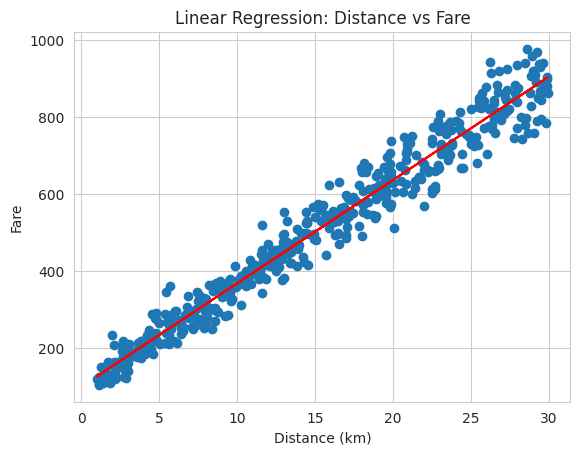

In [32]:
plt.scatter(df["Distance_km"], df["Fare"])

plt.plot(
    df["Distance_km"],
    df["Predicted_Fare"],
    color="red"
)

plt.title("Linear Regression: Distance vs Fare")
plt.xlabel("Distance (km)")
plt.ylabel("Fare")

plt.show()

In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(y, df["Predicted_Fare"])

print("R-squared:", r2)

R-squared: 0.9651272231429836
